In [1]:
# CELL 1: Setup, Imports & Data Loading

# --- Core Libraries & Setup ---
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, auc, average_precision_score, balanced_accuracy_score, matthews_corrcoef, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.neural_network import MLPClassifier
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
from scipy.stats import chi2_contingency
from tab_transformer_pytorch import TabTransformer
from pathlib import Path
import copy
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
OUT_DIR = Path("output")
OUT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
import random
random.seed(SEED); np.random.seed(SEED)
try:
    torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
except Exception:
    pass

# --- Global Settings ---
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 12, 'figure.figsize': (10, 8)})

# --- Load Data (NEW 80/20 SPLIT) ---
# [Edit] Directly read the training and test sets that have been split by `feature_selection`
train_df = pd.read_csv('GSE240671_train_80.csv', index_col=0)
test_df = pd.read_csv('GSE240671_test_20.csv', index_col=0)

target_col = 'sentinel_lymph_node' 
target_map = {'no': 0, 'yes': 1}

# Extract 80% of the development set
y_train_full = train_df[target_col].map(target_map)
X_train_full = train_df.drop(columns=[target_col])

# Extract a 20% independent test set (thoroughly frozen)
y_test_holdout = test_df[target_col].map(target_map)
X_test_holdout = test_df.drop(columns=[target_col])

print(f"80% Train ({len(X_train_full)} samples) and 20% Test ({len(X_test_holdout)} samples) loaded successfully.")

80% Train (55 samples) and 20% Test (14 samples) loaded successfully.


In [7]:
# CELL 2: Define All Helper Functions

def process_fold_features(X_train, y_train, X_test):
    """Encapsulates all feature engineering for a single fold (GSE240671 version)."""
    
    # --- 1. Process Categorical (Clinical) Features ---
    
    # 1a. Define the clinical columns for GSE240671
    known_cat_cols = [
        'tissue', 'timing_biopsies', 'sex', 'age_diagnostic', 'patient_id',
        'statut_menopausal', 'tum_size_max_diagnostic_(larger_diameter_in_mm)',
        'molecular_category', 'ki67_binary_(1_>_and_=_15%_et_0_<15%)',
        'rcb_category', 'unifocal', 'grade', 'node_invasion', 
        'nac_category', 'nac_herceptin_binary', 'breast_conservative_surgery',
        'radiotherapy_binary', 'hormonotherapy_type_category', 
        'sequencing_batch', 'mapped_to_intergenic_(%_reads)'
    ]
    
    cat_cols = [col for col in known_cat_cols if col in X_train.columns]
    
    X_train_cat = X_train[cat_cols].copy()
    X_test_cat = X_test[cat_cols].copy()

    # 1b. Remove unnecessary columns as required
    cols_to_drop = ['tissue', 'patient_id', 'sequencing_batch']
    X_train_cat.drop(columns=cols_to_drop, inplace=True, errors='ignore')
    X_test_cat.drop(columns=cols_to_drop, inplace=True, errors='ignore')

    # 1c. Distinguishing Between Numeric Columns and Categorical Columns
    numeric_cols = [
        'age_diagnostic', 
        'tum_size_max_diagnostic_(larger_diameter_in_mm)',
        'mapped_to_intergenic_(%_reads)'
    ]
    
    # Automatically Clear Numeric Columns
    def clean_numeric_cols(df, cols):
        for col in cols:
            if col in df.columns: 
                df[col] = pd.to_numeric(df[col], errors='coerce')
        return df

    X_train_cat = clean_numeric_cols(X_train_cat, numeric_cols)
    X_test_cat = clean_numeric_cols(X_test_cat, numeric_cols)

    # 1d. Interpolating Missing Values
    imputation_values = {}
    for col in X_train_cat.columns:
        if col in numeric_cols:
            imputation_values[col] = X_train_cat[col].median()
        else:
            imputation_values[col] = X_train_cat[col].mode().get(0) # .get(0)防止空mode
            
    for col, value in imputation_values.items():
        if value is not None:
            X_train_cat[col] = X_train_cat[col].fillna(value)
            X_test_cat[col] = X_test_cat[col].fillna(value)

    # 1e. Binning of Digital Features
    # Convert all numerical variables to categorical variables to perform a chi-square test.
    binned_features = []
    for col in numeric_cols:
        if col in X_train_cat.columns:
            new_col_name = f"{col}_category"
            
            # Use qcut for quantitative binning, with `duplicates=‘drop’` to handle duplicate values
            try:
                _, bins = pd.qcut(X_train_cat[col], q=5, retbins=True, duplicates='drop')
                labels = [f'{col}_g{k + 1}' for k in range(len(bins) - 1)]
                
                for df in [X_train_cat, X_test_cat]:
                    df[new_col_name] = pd.cut(df[col], bins=bins, labels=labels, include_lowest=True)
                    df.drop(columns=[col], inplace=True)
                binned_features.append(new_col_name)
                
            except Exception as e:
                print(f"  Warning: Could not bin column {col}. Dropping it. Error: {e}")
                X_train_cat.drop(columns=[col], inplace=True, errors='ignore')
                X_test_cat.drop(columns=[col], inplace=True, errors='ignore')


    # 1f. Using the Chi-Square Test to Screen Features
    # The candidates are all remaining columns (the original classification column + the new binning column).
    candidate_for_chi2 = X_train_cat.columns.tolist()
    selected_categorical_features = []
    
    for col in candidate_for_chi2:
        try:
            crosstab = pd.crosstab(X_train_cat[col].astype('category'), y_train)
            if crosstab.shape[0] > 1 and crosstab.shape[1] > 1:
                p_value = chi2_contingency(crosstab)[1]
                if p_value < 0.05:
                    selected_categorical_features.append(col)
        except Exception as e:
            print(f"  Skipping chi2 for {col}: {e}")

    print(f"  Selected {len(selected_categorical_features)} clinical features: {selected_categorical_features}")

    # --- 2. Process Continuous (Gene) Features ---
    
    # 2a. Isolated Gene Column
    gene_cols = X_train.columns.drop(cat_cols, errors='ignore')
    X_train_cont_raw = X_train[gene_cols].copy()
    X_test_cont_raw = X_test[gene_cols].copy()

    # 2b. Handling Duplicate Gene Symbols
    X_train_cont_raw = X_train_cont_raw.T.groupby(level=0).sum().T
    all_gene_columns = X_train_cont_raw.columns
    X_test_cont_raw = X_test_cont_raw.T.groupby(level=0).sum().T.reindex(columns=all_gene_columns, fill_value=0)

    # 2c. Running DESeq2 on the current fold change
    significant_genes = []
    try:
        samples_df = pd.DataFrame({'condition': y_train})
        dds = DeseqDataSet(counts=X_train_cont_raw, metadata=samples_df, design='~condition')
        dds.deseq2()
        stat_res = DeseqStats(dds, contrast=['condition', 1, 0]) # 1='yes', 0='no'
        stat_res.summary()
        results_df = stat_res.results_df
        
        significant_genes = results_df[
            (results_df['padj'] < 0.05) & (abs(results_df['log2FoldChange']) > 1.0)
        ].index.tolist()
    except Exception as e:
        print(f"  DESeq2 analysis failed in this fold: {e}")

    print(f"  Found {len(significant_genes)} significant genes.")

    return X_train_cat, X_test_cat, selected_categorical_features, X_train_cont_raw, X_test_cont_raw, significant_genes


def train_tt_in_cv(X_cat_train, X_cont_train, y_train, X_cat_test, X_cont_test, cat_cardinalities, fold_name=""):
    """
    A robust training function for Tab-Transformer inside a CV loop,
    featuring Early Stopping, Validation Split, and Parameter Counting.
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # --- 1. Split 10% Validation Set for Early Stopping ---
    indices = np.arange(len(y_train))
    try:
        train_idx, val_idx = train_test_split(indices, test_size=0.1, stratify=y_train.values, random_state=42)
    except ValueError:
        train_idx, val_idx = train_test_split(indices, test_size=0.1, random_state=42)
        
    y_train_full = y_train.values
    y_tr = torch.tensor(y_train_full[train_idx], dtype=torch.long).to(device)
    y_val = torch.tensor(y_train_full[val_idx], dtype=torch.long).to(device)
    
    # Safely handle potentially empty tensors
    X_cat_tr = X_cat_train[train_idx].to(device) if X_cat_train.shape[1] > 0 else torch.empty(len(train_idx), 0, dtype=torch.long).to(device)
    X_cat_val = X_cat_train[val_idx].to(device) if X_cat_train.shape[1] > 0 else torch.empty(len(val_idx), 0, dtype=torch.long).to(device)
    
    X_cont_tr = X_cont_train[train_idx].to(device) if X_cont_train.shape[1] > 0 else torch.empty(len(train_idx), 0).to(device)
    X_cont_val = X_cont_train[val_idx].to(device) if X_cont_train.shape[1] > 0 else torch.empty(len(val_idx), 0).to(device)

    # --- 2. Model Initialization & Parameter Counting ---
    model = TabTransformer(
        categories=cat_cardinalities,
        num_continuous=X_cont_train.shape[1],
        dim=32, dim_out=2, depth=6, heads=8
    ).to(device)
    
    if fold_name == "Final":
        num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"  [TabTransformer] Trainable Parameters: {num_params}")

    optimizer = optim.AdamW(model.parameters(), lr=1e-4)
    
    pos = float((y_train_full[train_idx] == 1).sum())
    neg = float((y_train_full[train_idx] == 0).sum())
    w = torch.tensor([0.5, 0.5], dtype=torch.float32) if pos == 0 or neg == 0 else torch.tensor([neg/(pos+neg), pos/(pos+neg)], dtype=torch.float32)
    criterion = nn.CrossEntropyLoss(weight=w.to(device))
    
    # --- 3. Training Loop with Early Stopping ---
    best_val_loss = float('inf')
    patience = 5
    patience_counter = 0
    best_model_state = None
    
    train_losses = []
    val_losses = []

    for epoch in range(100): 
        model.train()
        optimizer.zero_grad()
        output = model(X_cat_tr, X_cont_tr)
        loss = criterion(output, y_tr)
        loss.backward()
        optimizer.step()
        
        model.eval()
        with torch.no_grad():
            val_output = model(X_cat_val, X_cont_val)
            val_loss = criterion(val_output, y_val).item()
            
        train_losses.append(loss.item())
        val_losses.append(val_loss)
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_model_state = copy.deepcopy(model.state_dict())
        else:
            patience_counter += 1
            
        if patience_counter >= patience:
            if fold_name == "Final":
                print(f"  [Early Stopping] Triggered at epoch {epoch+1}")
            break
            
    # --- 4. Restore Best Weights & Plot Curve ---
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        
    if fold_name == "Final":
        plt.figure(figsize=(8, 6))
        plt.plot(train_losses, label='Train Loss', color='#1f77b4', linewidth=2)
        plt.plot(val_losses, label='Validation Loss', color='#ff7f0e', linewidth=2)
        plt.title('TabTransformer Training vs Validation Loss (GSE240671)')
        plt.xlabel('Epochs')
        plt.ylabel('CrossEntropy Loss')
        plt.legend()
        sns.despine()
        curve_path = OUT_DIR / "GSE240671_tabtransformer_loss_curve.png"
        plt.savefig(curve_path, dpi=300, bbox_inches="tight")
        plt.close()
        print(f"  [Plot] Saved Loss Curve to: {curve_path}")

    # --- 5. Evaluate on actual Hold-out / Test Set ---
    model.eval()
    with torch.no_grad():
        test_output = model(X_cat_test.to(device), X_cont_test.to(device))
        y_pred_proba = torch.softmax(test_output, dim=1).cpu().numpy()[:, 1]
        
    return y_pred_proba

def get_comprehensive_metrics(y_true, y_prob):
    """
    A unified evaluator returning 7 core metrics to satisfy stringent reviewer demands.
    """
    y_pred = (y_prob >= 0.5).astype(int)
    
    # 1. Base Metrics
    roc_auc = roc_auc_score(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)
    cr = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    macro_f1 = cr['macro avg']['f1-score']
    
    # 2. Imbalance-Aware Metrics
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    mcc = matthews_corrcoef(y_true, y_pred)
    
    # 3. Sensitivity & Specificity
    cm = confusion_matrix(y_true, y_pred)
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    else:
        sensitivity, specificity = 0.0, 0.0
        
    return {
        'ROC-AUC': roc_auc,
        'PR-AUC': pr_auc,
        'Macro F1': macro_f1,
        'Bal. Acc.': bal_acc,
        'MCC': mcc,
        'Sensitivity': sensitivity,
        'Specificity': specificity
    }

def get_bootstrap_ci(y_true, y_prob, metric_func, n_boot=1000, alpha=0.05):
    """
    Bootstrap resampling to estimate 95% CI for a given metric.
    Includes safeguards for extremely small/imbalanced datasets (e.g., GSE240671).
    """
    boot_scores = []
    y_true_arr = np.array(y_true)
    y_prob_arr = np.array(y_prob)
    
    for _ in range(n_boot):
        try:
            idx = resample(np.arange(len(y_true_arr)), stratify=y_true_arr)
            score = metric_func(y_true_arr[idx], y_prob_arr[idx])
            boot_scores.append(score)
        except ValueError:
            continue
            
    if len(boot_scores) == 0:
        return np.nan, np.nan, np.nan
        
    boot_scores = np.array(boot_scores)
    lower = np.percentile(boot_scores, 100 * (alpha / 2))
    upper = np.percentile(boot_scores, 100 * (1 - alpha / 2))
    return np.mean(boot_scores), lower, upper


print("Helper functions defined.")

Helper functions defined.


In [3]:
# CELL 3: The Main Cross-Validation Loop

N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

# Create a dictionary to store results
results = {'AUCs': {}, 'TPRs': {}}
mean_fpr = np.linspace(0, 1, 100)
cr_macro = {}
cr_weighted = {}

# --- Start the Loop ---
# [Modify] Perform a 5-fold split only within this 80% training set (X_train_full, y_train_full)
for i, (train_index, test_index) in enumerate(skf.split(X_train_full, y_train_full)):
    print(f"\n========== FOLD {i + 1}/{N_SPLITS} ========== ")
    X_train, X_test = X_train_full.iloc[train_index], X_train_full.iloc[test_index]
    y_train, y_test = y_train_full.iloc[train_index], y_train_full.iloc[test_index]

    # --- 1. Perform feature engineering for the current fold ---
    X_train_cat, X_test_cat, sel_cat_feats, X_train_cont_raw, X_test_cont_raw, sig_genes = process_fold_features(
        X_train, y_train, X_test)

    # --- 2. Prepare final data subsets for this fold ---
    has_cont = (len(sig_genes) > 0)
    has_cat = (len(sel_cat_feats) > 0)
    
    # Scikit-learn data
    scaler = StandardScaler()
    onehot = OneHotEncoder(handle_unknown='ignore', sparse_output=False, dtype=int)
    
    if has_cont:
        X_train_cont_final = pd.DataFrame(scaler.fit_transform(np.log1p(X_train_cont_raw[sig_genes])), index=X_train.index, columns=sig_genes)
        X_test_cont_final = pd.DataFrame(scaler.transform(np.log1p(X_test_cont_raw[sig_genes])), index=X_test.index, columns=sig_genes)
    else:
        X_train_cont_final = pd.DataFrame(index=X_train.index)
        X_test_cont_final = pd.DataFrame(index=X_test.index)

    if has_cat:
        X_train_cat_final = pd.DataFrame(onehot.fit_transform(X_train_cat[sel_cat_feats]), index=X_train.index, columns=onehot.get_feature_names_out())
        X_test_cat_final = pd.DataFrame(onehot.transform(X_test_cat[sel_cat_feats]), index=X_test.index, columns=onehot.get_feature_names_out())
    else:
        X_train_cat_final = pd.DataFrame(index=X_train.index)
        X_test_cat_final = pd.DataFrame(index=X_test.index)
        
    X_train_comb = pd.concat([X_train_cat_final, X_train_cont_final], axis=1)
    X_test_comb = pd.concat([X_test_cat_final, X_test_cont_final], axis=1)

    # Tab-Transformer data
    if has_cat:
        ordinal = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1);
        ordinal.fit(X_train_cat[sel_cat_feats])
        X_train_cat_ord = torch.tensor(ordinal.transform(X_train_cat[sel_cat_feats]), dtype=torch.long)
        X_test_cat_ord = torch.tensor(ordinal.transform(X_test_cat[sel_cat_feats]), dtype=torch.long)
        cat_cards = [len(cats) for cats in ordinal.categories_]
    else:
        X_train_cat_ord = torch.empty(len(X_train), 0, dtype=torch.long)
        X_test_cat_ord = torch.empty(len(X_test), 0, dtype=torch.long)
        cat_cards = []

    if has_cont:
        X_train_cont_tensor = torch.tensor(X_train_cont_final.values, dtype=torch.float32)
        X_test_cont_tensor = torch.tensor(X_test_cont_final.values, dtype=torch.float32)
    else:
        X_train_cont_tensor = torch.empty(len(X_train), 0)
        X_test_cont_tensor = torch.empty(len(X_test), 0)

    # --- 3. Run all experiments for this fold ---
    models_to_run = {}
    
    if has_cont:
        models_to_run['TT_cont'] = lambda: train_tt_in_cv(
            torch.empty(len(X_train), 0, dtype=torch.long), X_train_cont_tensor, y_train,
            torch.empty(len(X_test), 0, dtype=torch.long), X_test_cont_tensor, [])
        models_to_run['RF_cont'] = lambda: RandomForestClassifier(
            n_estimators=100, random_state=42, n_jobs=-1, class_weight="balanced_subsample"
        ).fit(X_train_cont_final, y_train).predict_proba(X_test_cont_final)[:, 1]
        models_to_run['LR_cont'] = lambda: LogisticRegression(
            random_state=42, max_iter=1000, class_weight="balanced"
        ).fit(X_train_cont_final, y_train).predict_proba(X_test_cont_final)[:, 1]
        models_to_run['LASSO_cont'] = lambda: LogisticRegression(
            penalty='l1', solver='liblinear', C=1.0, random_state=42, class_weight="balanced"
        ).fit(X_train_cont_final, y_train).predict_proba(X_test_cont_final)[:, 1]
        
        # [NEW] XGBoost (gene only)
        models_to_run['XGB_cont'] = lambda: XGBClassifier(
            n_estimators=100, max_depth=4, learning_rate=0.05, eval_metric='logloss', random_state=42, 
            scale_pos_weight=(len(y_train)-y_train.sum())/y_train.sum() if y_train.sum() > 0 else 1
        ).fit(X_train_cont_final, y_train).predict_proba(X_test_cont_final)[:, 1]
        
        # [NEW] LightGBM (gene only)
        models_to_run['LGBM_cont'] = lambda: LGBMClassifier(
            n_estimators=100, max_depth=4, learning_rate=0.05, random_state=42, class_weight='balanced', verbose=-1
        ).fit(X_train_cont_final, y_train).predict_proba(X_test_cont_final)[:, 1]
        
        # [NEW] CatBoost (gene only)
        models_to_run['CB_cont'] = lambda: CatBoostClassifier(
            iterations=100, depth=4, learning_rate=0.05, random_seed=42, auto_class_weights='Balanced', verbose=False
        ).fit(X_train_cont_final, y_train).predict_proba(X_test_cont_final)[:, 1]
        
        # [NEW] MLP (gene only)
        models_to_run['MLP_cont'] = lambda: MLPClassifier(
            hidden_layer_sizes=(32, 16), max_iter=500, random_state=42, early_stopping=True
        ).fit(X_train_cont_final, y_train).predict_proba(X_test_cont_final)[:, 1]

    if has_cat:
        models_to_run['TT_cat'] = lambda: train_tt_in_cv(
            X_train_cat_ord, torch.empty(len(X_train), 0), y_train, X_test_cat_ord, torch.empty(len(X_test), 0),
            cat_cards)

    # Run the combined model only when both features are present.
    if has_cat and has_cont:
        models_to_run['TT_comb'] = lambda: train_tt_in_cv(
            X_train_cat_ord, X_train_cont_tensor, y_train,
            X_test_cat_ord, X_test_cont_tensor, cat_cards
        )
        models_to_run['RF_comb'] = lambda: RandomForestClassifier(
            n_estimators=100, random_state=42, n_jobs=-1, class_weight="balanced_subsample"
        ).fit(X_train_comb, y_train).predict_proba(X_test_comb)[:, 1]
        models_to_run['LR_comb'] = lambda: LogisticRegression(
            random_state=42, max_iter=1000, class_weight="balanced"
        ).fit(X_train_comb, y_train).predict_proba(X_test_comb)[:, 1]
        models_to_run['LASSO_comb'] = lambda: LogisticRegression(
            penalty='l1', solver='liblinear', C=1.0, random_state=42, class_weight="balanced"
        ).fit(X_train_comb, y_train).predict_proba(X_test_comb)[:, 1]
        
        # [NEW] XGBoost (combined)
        models_to_run['XGB_comb'] = lambda: XGBClassifier(
            n_estimators=100, max_depth=4, learning_rate=0.05, eval_metric='logloss', random_state=42, 
            scale_pos_weight=(len(y_train)-y_train.sum())/y_train.sum() if y_train.sum() > 0 else 1
        ).fit(X_train_comb, y_train).predict_proba(X_test_comb)[:, 1]
        
        # [NEW] LightGBM (combined)
        models_to_run['LGBM_comb'] = lambda: LGBMClassifier(
            n_estimators=100, max_depth=4, learning_rate=0.05, random_state=42, class_weight='balanced', verbose=-1
        ).fit(X_train_comb, y_train).predict_proba(X_test_comb)[:, 1]
        
        # [NEW] CatBoost (combined)
        models_to_run['CB_comb'] = lambda: CatBoostClassifier(
            iterations=100, depth=4, learning_rate=0.05, random_seed=42, auto_class_weights='Balanced', verbose=False
        ).fit(X_train_comb, y_train).predict_proba(X_test_comb)[:, 1]
        
        # [NEW] MLP (combined)
        models_to_run['MLP_comb'] = lambda: MLPClassifier(
            hidden_layer_sizes=(32, 16), max_iter=500, random_state=42, early_stopping=True
        ).fit(X_train_comb, y_train).predict_proba(X_test_comb)[:, 1]

    
    if not models_to_run:
        print(f"  Fold {i+1} skipped: No 'cat' or 'cont' features were found.")
        continue

    # Evaluate all models defined by this compromise
    for name, train_eval_func in models_to_run.items():
        if name not in results['AUCs']:
            results['AUCs'][name] = []
            results['TPRs'][name] = []
            cr_macro[name] = []
            cr_weighted[name] = []

        y_proba = train_eval_func()
        auc_score = roc_auc_score(y_test, y_proba)
        results['AUCs'][name].append(auc_score)

        fpr, tpr, _ = roc_curve(y_test, y_proba)
        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0
        results['TPRs'][name].append(interp_tpr)
        print(f"  {name}: AUC = {auc_score:.4f}")
        
        y_pred = (y_proba >= 0.5).astype(int)
        cr = classification_report(y_test, y_pred, output_dict=True, zero_division=0)

        cr_macro[name].append([
            cr["macro avg"]["precision"], cr["macro avg"]["recall"], cr["macro avg"]["f1-score"],
        ])
        cr_weighted[name].append([
            cr["weighted avg"]["precision"], cr["weighted avg"]["recall"], cr["weighted avg"]["f1-score"],
        ])

print("\n========== CROSS-VALIDATION COMPLETE ==========")


========== FOLD 1/5 ========== 
  Selected 1 clinical features: ['node_invasion']


Fitting size factors...
... done in 0.04 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 1.41 seconds.

Fitting dispersion trend curve...
... done in 0.49 seconds.

Fitting MAP dispersions...
... done in 1.68 seconds.

Fitting LFCs...
... done in 1.61 seconds.

Calculating cook's distance...
... done in 0.07 seconds.

Replacing 895 outlier genes.

Fitting dispersions...
... done in 0.13 seconds.

Fitting MAP dispersions...
... done in 0.13 seconds.

Fitting LFCs...
... done in 0.13 seconds.

Running Wald tests...
... done in 1.42 seconds.



Log2 fold change & Wald test p-value: condition 1 vs 0
             baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
A1BG        77.935270       -0.193576  0.249243 -0.776656  0.437362       NaN
A1BG-AS1    85.097411       -0.174452  0.250014 -0.697770  0.485321       NaN
A1CF        52.902110       -0.316479  0.723931 -0.437168  0.661990       NaN
A2M       1592.422197        0.112289  0.308827  0.363599  0.716158  0.893710
A2M-AS1     76.873493       -0.043345  0.304460 -0.142365  0.886792       NaN
...               ...             ...       ...       ...       ...       ...
ZYG11A     154.735271        0.461958  0.426824  1.082313  0.279114  0.653904
ZYG11B     378.291966       -0.384810  0.149326 -2.576969  0.009967  0.188740
ZYX        464.004387       -0.028883  0.242085 -0.119307  0.905032  0.969692
ZZEF1     1463.279395        0.110503  0.150313  0.735149  0.462249  0.769294
ZZZ3       545.088649       -0.091929  0.168056 -0.547016  0.584368  0.839592

[39376 r

...

Log2 fold change & Wald test p-value: condition 1 vs 0
             baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
A1BG        75.290465       -0.279024  0.277592 -1.005159  0.314820  0.768754
A1BG-AS1    80.655265       -0.135469  0.254690 -0.531898  0.594797  0.895088
A1CF        54.316321       -0.697955  0.729751 -0.956430  0.338855  0.782817
A2M       1640.262997        0.046278  0.294170  0.157317  0.874995  0.976432
A2M-AS1     75.088293        0.235800  0.305608  0.771574  0.440367  0.833636
...               ...             ...       ...       ...       ...       ...
ZYG11A     161.519591        0.403726  0.426611  0.946357  0.343967  0.785981
ZYG11B     390.214902       -0.202174  0.172317 -1.173267  0.240689  0.715782
ZYX        501.238404        0.092685  0.241574  0.383672  0.701222  0.931496
ZZEF1     1569.247049        0.027489  0.149612  0.183737  0.854220  0.970615
ZZZ3       555.014184       -0.203418  0.159193 -1.277810  0.201316  0.683601

[39376 r

Fitting size factors...
... done in 0.04 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 1.55 seconds.

Fitting dispersion trend curve...
... done in 0.46 seconds.

Fitting MAP dispersions...
... done in 1.65 seconds.

Fitting LFCs...
... done in 1.98 seconds.

Calculating cook's distance...
... done in 0.07 seconds.

Replacing 1126 outlier genes.

Fitting dispersions...
... done in 0.16 seconds.

Fitting MAP dispersions...
... done in 0.14 seconds.

Fitting LFCs...
... done in 0.14 seconds.

Running Wald tests...
... done in 1.43 seconds.



Log2 fold change & Wald test p-value: condition 1 vs 0
             baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
A1BG        75.386379       -0.464118  0.289787 -1.601582  0.109248       NaN
A1BG-AS1    86.247633       -0.344068  0.291357 -1.180915  0.237637       NaN
A1CF        54.429627       -0.224117  0.681581 -0.328818  0.742293       NaN
A2M       1621.985884        0.292727  0.293081  0.998794  0.317895  0.806204
A2M-AS1     74.166281        0.265777  0.320899  0.828225  0.407543       NaN
...               ...             ...       ...       ...       ...       ...
ZYG11A     168.747966        0.583655  0.434045  1.344687  0.178726  0.736977
ZYG11B     412.512700       -0.200090  0.173400 -1.153920  0.248533  0.782791
ZYX        478.937164       -0.174399  0.253055 -0.689176  0.490712  0.878808
ZZEF1     1459.314937       -0.046389  0.148443 -0.312501  0.754660  0.956266
ZZZ3       582.755896       -0.001839  0.172097 -0.010687  0.991473  0.997912

[39376 r

In [4]:
# CELL 4: Results Summary & Tables

def _cr_store_to_df(store: dict, label: str) -> pd.DataFrame:
    rows = []
    for name, arr in store.items():
        A = np.asarray(arr, dtype=float)
        mu = A.mean(axis=0); sd = A.std(axis=0)
        rows.append([
            name.replace("_", " ").title(),
            mu[0], sd[0], mu[1], sd[1], mu[2], sd[2],
        ])
    return pd.DataFrame(rows, columns=[
        "Model",
        f"{label} Precision (mean)", f"{label} Precision (std)",
        f"{label} Recall (mean)",    f"{label} Recall (std)",
        f"{label} F1 (mean)",        f"{label} F1 (std)",
    ]).sort_values("Model").reset_index(drop=True)

# --- AUC Summary Table ---
summary_data = []
for name, auc_list in results['AUCs'].items():
    summary_data.append({
        'Experiment': name.replace("_", " ").title(),
        'Mean AUC': np.mean(auc_list),
        'Std Dev (±)': np.std(auc_list)
    })

summary_cv_df = pd.DataFrame(summary_data).set_index('Experiment').sort_values(by='Mean AUC', ascending=False)

print("\n--- Final Cross-Validation Performance Summary (GSE240671) ---")
print("Metrics are reported as Mean ± Standard Deviation over 5 folds.")

try:
    display(summary_cv_df.style
            .format({'Mean AUC': '{:.3f}', 'Std Dev (±)': '{:.3f}'})
            .background_gradient(cmap='Greens', subset=['Mean AUC'])
            .bar(subset=['Std Dev (±)'], color='#d4edda', align='zero')
    )
except:
    print(summary_cv_df)

summary_cv_path = OUT_DIR / "GSE240671_cv_auc_summary.csv"
summary_cv_df.to_csv(summary_cv_path, index=True)
print(f"Saved CV AUC summary to: {summary_cv_path}")

# --- Classification Report Tables ---
macro_df = _cr_store_to_df(cr_macro, "Macro")
weighted_df = _cr_store_to_df(cr_weighted, "Weighted")

print("\n--- Classification Report (Macro avg) — 5-fold mean ± std ---")
try: display(macro_df)
except: print(macro_df)
print("\n--- Classification Report (Weighted avg) — 5-fold mean ± std ---")
try: display(weighted_df)
except: print(weighted_df)

macro_path = OUT_DIR / "GSE240671_cv_classification_report_macro.csv"
weighted_path = OUT_DIR / "GSE240671_cv_classification_report_weighted.csv"
macro_df.to_csv(macro_path, index=False)
weighted_df.to_csv(weighted_path, index=False)
print(f"Saved CR tables to:\n- {macro_path}\n- {weighted_path}")


--- Final Cross-Validation Performance Summary (GSE240671) ---
Metrics are reported as Mean ± Standard Deviation over 5 folds.


,Mean AUC,Std Dev (±)
Experiment,,
Tt Comb,0.811,0.120
Tt Cat,0.781,0.106
Lasso Comb,0.767,0.082
Rf Comb,0.756,0.107
Lr Comb,0.742,0.116
Cb Comb,0.733,0.082
Rf Cont,0.724,0.165
Cb Cont,0.719,0.106
Lr Cont,0.692,0.086


Saved CV AUC summary to: output\GSE240671_cv_auc_summary.csv

--- Classification Report (Macro avg) — 5-fold mean ± std ---


,Model,Macro Precision (mean),Macro Precision (std),Macro Recall (mean),Macro Recall (std),Macro F1 (mean),Macro F1 (std)
0,Cb Comb,0.654470,0.232626,0.611111,0.097816,0.602645,0.139197
1,Cb Cont,0.573636,0.235337,0.615278,0.173894,0.573348,0.177796
2,Lasso Comb,0.605985,0.166103,0.687500,0.180556,0.619687,0.153818
3,Lasso Cont,0.539232,0.132608,0.587500,0.098953,0.550833,0.117391
4,Lgbm Comb,0.535657,0.138851,0.583333,0.091287,0.547226,0.121462
5,Lgbm Cont,0.535657,0.138851,0.583333,0.091287,0.547226,0.121462
6,Lr Comb,0.647652,0.240098,0.577778,0.146355,0.583234,0.163736
7,Lr Cont,0.613485,0.209329,0.576389,0.148163,0.583234,0.163736
8,Mlp Comb,0.537727,0.232560,0.516667,0.193729,0.484685,0.177199
9,Mlp Cont,0.375758,0.144132,0.444444,0.139443,0.366190,0.124398



--- Classification Report (Weighted avg) — 5-fold mean ± std ---


,Model,Weighted Precision (mean),Weighted Precision (std),Weighted Recall (mean),Weighted Recall (std),Weighted F1 (mean),Weighted F1 (std)
0,Cb Comb,0.777617,0.099086,0.818182,0.057496,0.779682,0.060777
1,Cb Cont,0.735041,0.157162,0.800000,0.089072,0.754367,0.112483
2,Lasso Comb,0.788430,0.107735,0.781818,0.044536,0.767821,0.054092
3,Lasso Cont,0.730106,0.055994,0.745455,0.089072,0.727879,0.053014
4,Lgbm Comb,0.710579,0.107616,0.745455,0.106017,0.716514,0.096006
5,Lgbm Cont,0.710579,0.107616,0.745455,0.106017,0.716514,0.096006
6,Lr Comb,0.766460,0.112828,0.763636,0.123315,0.747918,0.102381
7,Lr Cont,0.744288,0.109691,0.763636,0.123315,0.747288,0.107439
8,Mlp Comb,0.703058,0.159114,0.636364,0.162623,0.636396,0.134128
9,Mlp Cont,0.534215,0.244660,0.490909,0.204090,0.479740,0.219943


Saved CR tables to:
- output\GSE240671_cv_classification_report_macro.csv
- output\GSE240671_cv_classification_report_weighted.csv



--- Generating Plot 1: Mean ROC Curves on Continuous Features Only (GSE240671) ---
Saved figure to: output\GSE240671_cv_roc_only_continuous.png


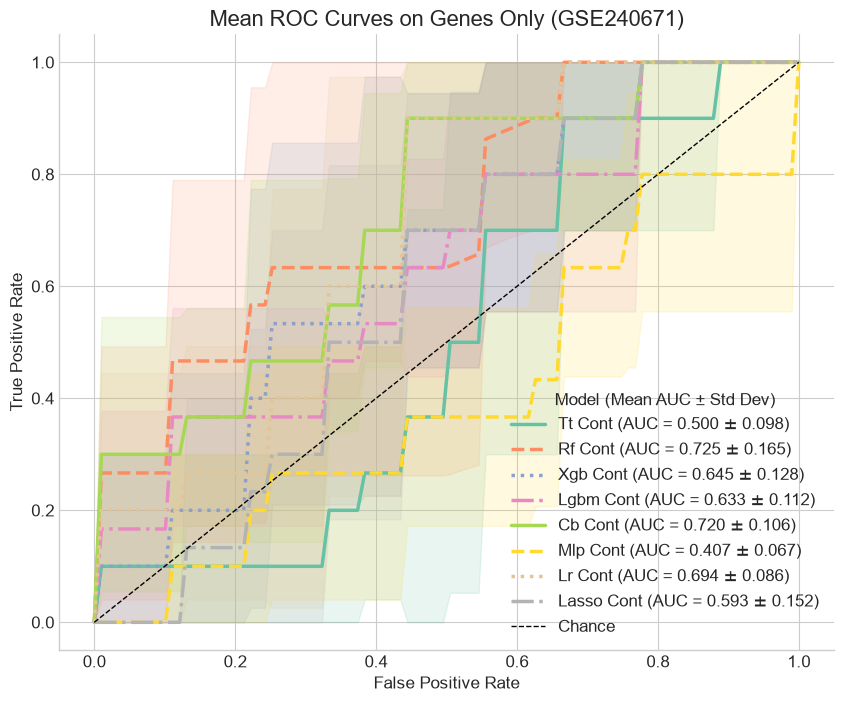


--- Generating Plot 2: Tab-Transformer Ablation Study (GSE240671) ---
Saved figure to: output\GSE240671_cv_roc_tt_internal.png


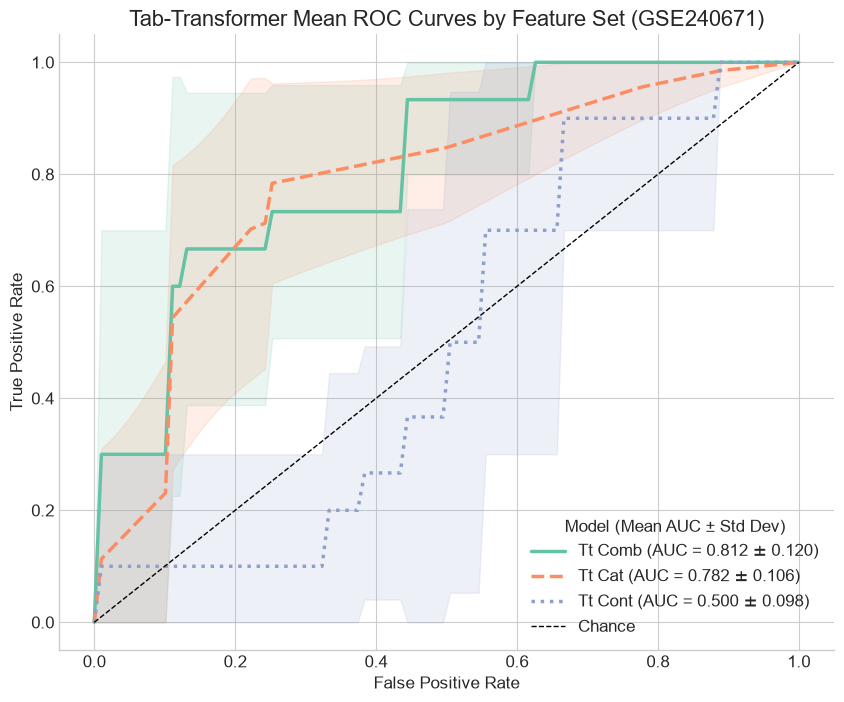


--- Generating Plot 3: Final Model Showdown on Combined Features (GSE240671) ---
Saved figure to: output\GSE240671_cv_roc_combined.png


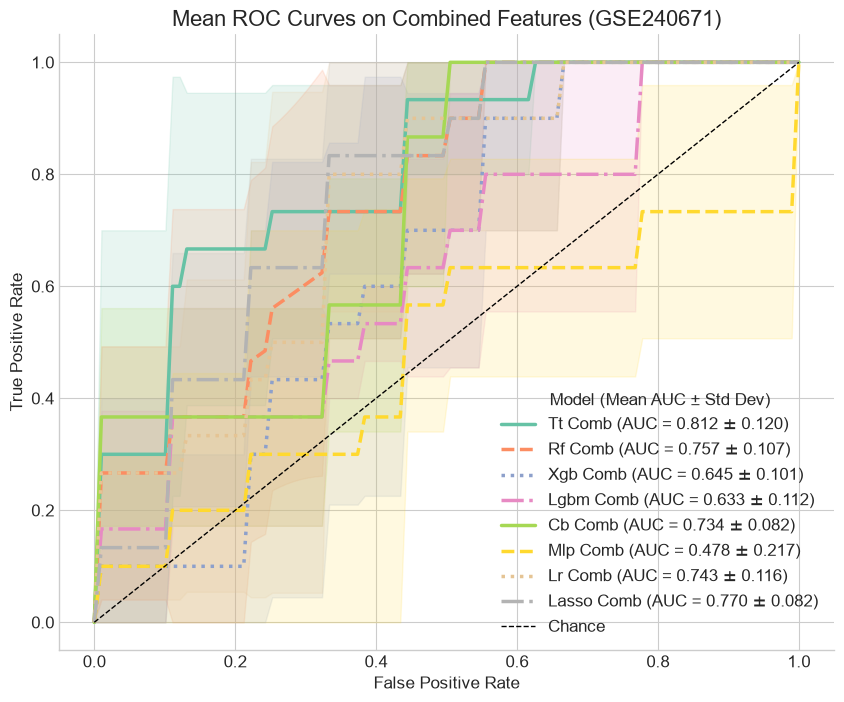

In [5]:
# CELL 5: Generate Final Comparative Plots

def plot_mean_roc_curves_with_std(results_tprs, results_aucs, model_keys, title, save_path=None):
    """
    Helper function to plot multiple mean ROC curves from CV results,
    including a shaded standard deviation band for each curve.
    """
    plt.figure(figsize=(10, 8))
    colors = sns.color_palette('Set2', n_colors=len(model_keys))
    linestyles = ['-', '--', ':', '-.']
    plotted_keys = []

    for i, key in enumerate(model_keys):
        if key not in results_tprs or not results_tprs[key]:
            print(f"Warning: No results found for '{key}'. Skipping this curve.")
            continue
        plotted_keys.append(key)
        
        tpr_array = np.array(results_tprs[key])
        mean_tprs = tpr_array.mean(axis=0); mean_tprs[-1] = 1.0
        mean_auc = auc(mean_fpr, mean_tprs)
        std_auc = np.std(results_aucs[key])
        std_tpr = tpr_array.std(axis=0)
        tprs_upper = np.minimum(mean_tprs + std_tpr, 1)
        tprs_lower = np.maximum(mean_tprs - std_tpr, 0)
        
        label_text = f'{key.replace("_", " ").title()} (AUC = {mean_auc:.3f} $\\pm$ {std_auc:.3f})'
        plt.plot(mean_fpr, mean_tprs, color=colors[i], linestyle=linestyles[i % len(linestyles)], lw=2.5,
                 label=label_text)
        plt.fill_between(mean_fpr, tprs_lower, tprs_upper, color=colors[i], alpha=0.15)
    
    if not plotted_keys:
        print(f"No models to plot for '{title}'. Skipping figure.")
        plt.close()
        return

    plt.plot([0, 1], [0, 1], color='black', lw=1, linestyle='--', label='Chance')
    plt.title(title, fontsize=16)
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
    plt.legend(loc="lower right", title="Model (Mean AUC ± Std Dev)");
    plt.grid(True); sns.despine()
    
    if save_path is not None:
        plt.savefig(save_path, dpi=220, bbox_inches="tight")
        print(f"Saved figure to: {save_path}")
    plt.show()


# ==============================================================================
# Generate the three plots using the new function
# ==============================================================================

# --- Plot 1: Continuous Features Only ---
print("\n--- Generating Plot 1: Mean ROC Curves on Continuous Features Only (GSE240671) ---")
plot_mean_roc_curves_with_std(
    results['TPRs'],
    results['AUCs'],
    ['TT_cont', 'RF_cont','XGB_cont', 'LGBM_cont','CB_cont', 'MLP_cont', 'LR_cont', 'LASSO_cont'],
    "Mean ROC Curves on Genes Only (GSE240671)",
    save_path=OUT_DIR / "GSE240671_cv_roc_only_continuous.png"
)

# --- Plot 2: Tab-Transformer Ablation Study ---
print("\n--- Generating Plot 2: Tab-Transformer Ablation Study (GSE240671) ---")
plot_mean_roc_curves_with_std(
    results['TPRs'],
    results['AUCs'],
    ['TT_comb', 'TT_cat', 'TT_cont'],
    "Tab-Transformer Mean ROC Curves by Feature Set (GSE240671)",
    save_path=OUT_DIR / "GSE240671_cv_roc_tt_internal.png"
)

# --- Plot 3: Combined Features Showdown ---
print("\n--- Generating Plot 3: Final Model Showdown on Combined Features (GSE240671) ---")
plot_mean_roc_curves_with_std(
    results['TPRs'],
    results['AUCs'],
    ['TT_comb', 'RF_comb', 'XGB_comb', 'LGBM_comb','CB_comb', 'MLP_comb', 'LR_comb', 'LASSO_comb'],
    "Mean ROC Curves on Combined Features (GSE240671)",
    save_path=OUT_DIR / "GSE240671_cv_roc_combined.png"
)

In [8]:
# ==============================================================================
# [Addition] Final Evaluation: Process features on 80% of the full training set and validate on the remaining 20% of the test set
# ==============================================================================
print("\n========== FINAL EVALUATION ON 20% HOLD-OUT TEST SET (GSE240671) ==========")

print("Processing final features on 80% Train -> applying to 20% Test...")
X_train_cat_full, X_test_cat_full, sel_cat_feats_full, X_train_cont_raw_full, X_test_cont_raw_full, sig_genes_full = process_fold_features(
    X_train_full, y_train_full, X_test_holdout
)

# --- Feature Transformation and Merging ---
has_cont_full = len(sig_genes_full) > 0
has_cat_full = len(sel_cat_feats_full) > 0

scaler_full = StandardScaler()
onehot_full = OneHotEncoder(handle_unknown='ignore', sparse_output=False, dtype=int)

if has_cont_full:
    X_train_cont_final_full = pd.DataFrame(scaler_full.fit_transform(np.log1p(X_train_cont_raw_full[sig_genes_full])), index=X_train_full.index, columns=sig_genes_full)
    X_test_cont_final_full = pd.DataFrame(scaler_full.transform(np.log1p(X_test_cont_raw_full[sig_genes_full])), index=X_test_holdout.index, columns=sig_genes_full)
    X_train_cont_tensor_full = torch.tensor(X_train_cont_final_full.values, dtype=torch.float32)
    X_test_cont_tensor_full = torch.tensor(X_test_cont_final_full.values, dtype=torch.float32)
else:
    X_train_cont_final_full = pd.DataFrame(index=X_train_full.index)
    X_test_cont_final_full = pd.DataFrame(index=X_test_holdout.index)
    X_train_cont_tensor_full = torch.empty(len(X_train_full), 0)
    X_test_cont_tensor_full = torch.empty(len(X_test_holdout), 0)

if has_cat_full:
    X_train_cat_final_full = pd.DataFrame(onehot_full.fit_transform(X_train_cat_full[sel_cat_feats_full]), index=X_train_full.index, columns=onehot_full.get_feature_names_out())
    X_test_cat_final_full = pd.DataFrame(onehot_full.transform(X_test_cat_full[sel_cat_feats_full]), index=X_test_holdout.index, columns=onehot_full.get_feature_names_out())
    
    ordinal_full = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    ordinal_full.fit(X_train_cat_full[sel_cat_feats_full])
    X_train_cat_ord_full = torch.tensor(ordinal_full.transform(X_train_cat_full[sel_cat_feats_full]), dtype=torch.long)
    X_test_cat_ord_full = torch.tensor(ordinal_full.transform(X_test_cat_full[sel_cat_feats_full]), dtype=torch.long)
    cat_cards_full = [len(cats) for cats in ordinal_full.categories_]
else:
    X_train_cat_final_full = pd.DataFrame(index=X_train_full.index)
    X_test_cat_final_full = pd.DataFrame(index=X_test_holdout.index)
    X_train_cat_ord_full = torch.empty(len(X_train_full), 0, dtype=torch.long)
    X_test_cat_ord_full = torch.empty(len(X_test_holdout), 0, dtype=torch.long)
    cat_cards_full = []

X_train_comb_full = pd.concat([X_train_cat_final_full, X_train_cont_final_full], axis=1)
X_test_comb_full = pd.concat([X_test_cat_final_full, X_test_cont_final_full], axis=1)

# --- Final Evaluation ---
print("Training and evaluating final models on combined features...")
final_results = []

if has_cat_full and has_cont_full:
    final_models = {
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight="balanced_subsample"),
        'XGBoost': XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.05, eval_metric='logloss', random_state=42, scale_pos_weight=(len(y_train_full)-y_train_full.sum())/y_train_full.sum() if y_train_full.sum() > 0 else 1),
        'LightGBM': LGBMClassifier(n_estimators=100, max_depth=4, learning_rate=0.05, random_state=42, class_weight='balanced', verbose=-1),
        'CatBoost': CatBoostClassifier(iterations=100, depth=4, learning_rate=0.05, random_seed=42, auto_class_weights='Balanced', verbose=False),
        'MLP': MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=500, random_state=42, early_stopping=True)
    }

    # (a) Run the standard machine learning models
    for name, clf in final_models.items():
        clf.fit(X_train_comb_full, y_train_full)
        y_prob = clf.predict_proba(X_test_comb_full)[:, 1]
        
        metrics_dict = get_comprehensive_metrics(y_test_holdout, y_prob)
        mean_auc, low_auc, high_auc = get_bootstrap_ci(y_test_holdout, y_prob, roc_auc_score)
        mean_pr, low_pr, high_pr = get_bootstrap_ci(y_test_holdout, y_prob, average_precision_score)

        metrics_dict['ROC-AUC'] = mean_auc
        metrics_dict['PR-AUC'] = mean_pr
        metrics_dict['ROC-AUC (95% CI)'] = f"[{low_auc:.3f} - {high_auc:.3f}]"
        metrics_dict['PR-AUC (95% CI)'] = f"[{low_pr:.3f} - {high_pr:.3f}]"
        metrics_dict['Model'] = name
        
        final_results.append(metrics_dict)

    # (b) Run TabTransformer
    tt_prob_full = train_tt_in_cv(
        X_train_cat_ord_full, X_train_cont_tensor_full, y_train_full, 
        X_test_cat_ord_full, X_test_cont_tensor_full, cat_cards_full, fold_name="Final"
    )

    tt_metrics_dict = get_comprehensive_metrics(y_test_holdout, tt_prob_full)
    tt_mean_auc, tt_low_auc, tt_high_auc = get_bootstrap_ci(y_test_holdout, tt_prob_full, roc_auc_score)
    tt_mean_pr, tt_low_pr, tt_high_pr = get_bootstrap_ci(y_test_holdout, tt_prob_full, average_precision_score)

    tt_metrics_dict['ROC-AUC'] = tt_mean_auc
    tt_metrics_dict['PR-AUC'] = tt_mean_pr
    tt_metrics_dict['ROC-AUC (95% CI)'] = f"[{tt_low_auc:.3f} - {tt_high_auc:.3f}]"
    tt_metrics_dict['PR-AUC (95% CI)'] = f"[{tt_low_pr:.3f} - {tt_high_pr:.3f}]"
    tt_metrics_dict['Model'] = 'TabTransformer (Comb)'

    final_results.append(tt_metrics_dict)

    # (c) Generate and Display Final Table
    cols_order = ['Model', 'ROC-AUC', 'ROC-AUC (95% CI)', 'PR-AUC', 'PR-AUC (95% CI)', 
                  'Macro F1', 'Bal. Acc.', 'MCC', 'Sensitivity', 'Specificity']

    final_df = pd.DataFrame(final_results)[cols_order].set_index('Model')

    print("\n--- FINAL HOLD-OUT PERFORMANCE (EXPANDED METRICS + CIs) ---")

    format_dict = {col: '{:.3f}' for col in final_df.columns if 'CI' not in col}

    try:
        display(final_df.style
                .format(format_dict)
                .background_gradient(cmap='Blues', subset=['ROC-AUC', 'PR-AUC'])
                .background_gradient(cmap='Greens', subset=['Sensitivity', 'Specificity'])
        )
    except:
        print(final_df)
    
    final_df.to_csv(OUT_DIR / "GSE240671_final_holdout_performance.csv")
    print(f"Saved final results to: {OUT_DIR / 'GSE240671_final_holdout_performance.csv'}")
else:
    print("Skipping final evaluation: Combined features not present after feature selection.")


========== FINAL EVALUATION ON 20% HOLD-OUT TEST SET (GSE240671) ==========
Processing final features on 80% Train -> applying to 20% Test...
  Selected 2 clinical features: ['node_invasion', 'tum_size_max_diagnostic_(larger_diameter_in_mm)_category']


Fitting size factors...
... done in 0.07 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 1.71 seconds.

Fitting dispersion trend curve...
... done in 0.56 seconds.

Fitting MAP dispersions...
... done in 1.75 seconds.

Fitting LFCs...
... done in 2.23 seconds.

Calculating cook's distance...
... done in 0.08 seconds.

Replacing 1130 outlier genes.

Fitting dispersions...
... done in 0.15 seconds.

Fitting MAP dispersions...
... done in 0.15 seconds.

Fitting LFCs...
... done in 0.14 seconds.

Running Wald tests...
... done in 1.52 seconds.



Log2 fold change & Wald test p-value: condition 1 vs 0
             baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
A1BG        79.043812       -0.301826  0.239308 -1.261246  0.207220  0.608085
A1BG-AS1    88.119102       -0.281543  0.233236 -1.207119  0.227386  0.624818
A1CF        51.734022       -0.398135  0.635186 -0.626801  0.530790       NaN
A2M       1707.217348        0.188408  0.262204  0.718557  0.472414  0.801934
A2M-AS1     78.609935        0.213961  0.271268  0.788744  0.430262  0.773798
...               ...             ...       ...       ...       ...       ...
ZYG11A     160.266992        0.519799  0.394410  1.317915  0.187532  0.587484
ZYG11B     405.113634       -0.255463  0.143387 -1.781629  0.074810  0.428201
ZYX        503.210111        0.019440  0.210317  0.092432  0.926354  0.978739
ZZEF1     1563.111795        0.052393  0.128879  0.406527  0.684356  0.898585
ZZZ3       581.562889       -0.060690  0.143227 -0.423730  0.671762  0.891883

[39376 r

,ROC-AUC,ROC-AUC (95% CI),PR-AUC,PR-AUC (95% CI),Macro F1,Bal. Acc.,MCC,Sensitivity,Specificity
Model,,,,,,,,,
Random Forest,0.646,[0.182 - 1.000],0.542,[0.226 - 1.000],0.417,0.455,-0.145,0.000,0.909
XGBoost,0.607,[0.182 - 1.000],0.448,[0.222 - 1.000],0.576,0.576,0.152,0.333,0.818
LightGBM,0.570,[0.000 - 1.000],0.568,[0.210 - 1.000],0.635,0.621,0.284,0.333,0.909
CatBoost,0.655,[0.182 - 1.000],0.564,[0.250 - 1.000],0.635,0.621,0.284,0.333,0.909
MLP,0.536,[0.273 - 0.818],0.325,[0.215 - 0.533],0.440,0.500,0.000,0.000,1.000
TabTransformer (Comb),0.879,[0.636 - 1.000],0.679,[0.359 - 1.000],0.417,0.455,-0.145,0.000,0.909


Saved final results to: output\GSE240671_final_holdout_performance.csv
